In [4]:
%pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.8 MB 10.1 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 10.2 MB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 13.9 MB/s eta 0:00:01
     |████████████████████████████████| 294 kB 22.0 MB/s eta 0:00:01
     |████████████████████████████████| 347 kB 16.1 MB/s eta 0:00:01
     |████████████████████████████████| 506 kB 15.9 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 14.3 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 5.8 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 12.2 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 11.8 MB/s eta 0:00:01     |███▉                            | 337 kB 11.8 MB/s eta 0:00:01
     |████████████████████████████████| 126 kB 49.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pi

In [5]:
# Loading the data
import json
import pandas as pd

pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 150)

with open("../data/cuad/train_separate_questions.json") as f:
    train = json.load(f)
with open("../data/cuad/test.json") as f:
    test = json.load(f)

print("train contracts:", len(train["data"]))
print("test contracts:", len(test["data"]))

train contracts: 408
test contracts: 102


In [6]:
# 1. Presence table: one row per (contract, category)
rows = []
for split, data in [("train", train), ("test", test)]:
    for doc in data["data"]:
        # Count how many spans each category has in this contract.
        spans = {}
        for qa in doc["paragraphs"][0]["qas"]:
            category = qa["question"].split('"')[1]
            spans[category] = spans.get(category, 0) + len(qa["answers"])

        for category, n in spans.items():
            rows.append({"split": split,
                         "contract": doc["title"],
                         "category": category,
                         "n_spans": n,
                         "present": n > 0})

presence = pd.DataFrame(rows)

print("rows:", len(presence), "(Total 510 x 41 =", 510 * 41, ")")
presence.head(42)

rows: 20910 (Total 510 x 41 = 20910 )


,split,contract,category,n_spans,present
0,train,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,1,True
1,train,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,5,True
2,train,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Agreement Date,1,True
3,train,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Effective Date,2,True
4,train,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Expiration Date,1,True
5,train,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Renewal Term,1,True
6,train,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Notice Period To Terminate Renewal,0,False
7,train,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Governing Law,1,True
8,train,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Most Favored Nation,0,False
9,train,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Non-Compete,0,False


In [7]:
# 2. Positive rate per category (train only)
train_only = presence[presence["split"] == "train"]

rate = train_only.groupby("category").agg(
    contracts_with=("present", "sum"),
    total_contracts=("present", "count"),
)
rate["pct"] = (100 * rate["contracts_with"] / rate["total_contracts"]).round(1)
rate = rate.sort_values("pct", ascending=False)

print(rate.to_string())

                                    contracts_with  total_contracts    pct
category                                                                  
Document Name                                  408              408  100.0
Parties                                        407              408   99.8
Agreement Date                                 377              408   92.4
Governing Law                                  354              408   86.8
Expiration Date                                335              408   82.1
Effective Date                                 320              408   78.4
Anti-Assignment                                302              408   74.0
Cap On Liability                               231              408   56.6
License Grant                                  205              408   50.2
Audit Rights                                   176              408   43.1
Termination For Convenience                    154              408   37.7
Post-Termination Services

In [8]:
# 3. How many categories are rare?
print("categories under 10%:", (rate["pct"] < 10).sum(), "of 41")
print("categories under 25%:", (rate["pct"] < 25).sum(), "of 41")
print("mean positive rate:", round(rate["pct"].mean(), 1), "%")
print()
print("Rarest 10 - these have too few examples for stable metrics:")
print(rate.tail(10).to_string())

categories under 10%: 9 of 41
categories under 25%: 23 of 41
mean positive rate: 32.6 %

Rarest 10 - these have too few examples for stable metrics:
                                   contracts_with  total_contracts   pct
category                                                                
Affiliate License-Licensee                     47              408  11.5
Joint Ip Ownership                             39              408   9.6
Non-Disparagement                              31              408   7.6
No-Solicit Of Customers                        27              408   6.6
Third Party Beneficiary                        26              408   6.4
Most Favored Nation                            25              408   6.1
Affiliate License-Licensor                     17              408   4.2
Price Restrictions                             15              408   3.7
Unlimited/All-You-Can-Eat-License              14              408   3.4
Source Code Escrow                             1

In [9]:
# 4. Contracts with a category vs total spans for it
compare = train_only.groupby("category").agg(
    contracts=("present", "sum"),
    spans=("n_spans", "sum"),
)
compare["pct_of_contracts"] = (100 * compare["contracts"] / 408).round(1)
compare["pct_of_spans"] = (100 * compare["spans"] / compare["spans"].sum()).round(1)
compare["spans_per_contract"] = (
    compare["spans"] / compare["contracts"].replace(0, pd.NA)
).round(2)
compare = compare.sort_values("pct_of_spans", ascending=False)

print("total spans:", compare["spans"].sum())
print(compare.to_string())


total spans: 11180
                                    contracts  spans  pct_of_contracts  pct_of_spans  spans_per_contract
category                                                                                                
Parties                                   407   2011              99.8          18.0                4.94
License Grant                             205    642              50.2           5.7                3.13
Cap On Liability                          231    554              56.6           5.0                2.40
Audit Rights                              176    538              43.1           4.8                3.06
Anti-Assignment                           302    517              74.0           4.6                1.71
Insurance                                 134    443              32.8           4.0                3.31
Document Name                             408    419             100.0           3.7                1.03
Agreement Date                      

In [10]:
# Span count per category, only in contracts where it appears
found = train_only[train_only["present"]]

spread = found.groupby("category")["n_spans"].agg(
    contracts="count", mean="mean", median="median", min="min", max="max"
).round(2).sort_values("max", ascending=False)

print(spread.to_string())


                                    contracts  mean  median  min  max
category                                                             
Parties                                   407  4.94     4.0    2   55
Post-Termination Services                 153  2.41     1.0    1   23
Rofr/Rofo/Rofn                             68  4.40     2.0    1   22
Audit Rights                              176  3.06     2.0    1   19
Insurance                                 134  3.31     2.0    1   16
Cap On Liability                          231  2.40     2.0    1   16
License Grant                             205  3.13     2.0    1   16
Ip Ownership Assignment                   101  2.54     2.0    1   15
Minimum Commitment                        133  2.53     2.0    1   14
Non-Transferable License                  116  2.20     2.0    1   12
Exclusivity                               147  2.26     2.0    1   12
Non-Compete                                96  2.08     2.0    1   12
Revenue/Profit Shari

`spans_per_contract` is why this is not one-label-per-contract. `Parties` averages
about 5 spans wherever it appears, and `Source Code Escrow` appears in only 12
contracts but carries 61 spans between them. A rare category is not necessarily a
category with few spans.

In [11]:
# 5. Did the official split skew the label distribution?
by_split = presence.groupby(["category", "split"])["present"].mean().unstack() * 100
by_split = by_split.round(1)
by_split["gap"] = (by_split["test"] - by_split["train"]).abs().round(1)

print("Largest train/test gaps (percentage points):")
print(by_split.sort_values("gap", ascending=False).head(10).to_string())
print()
print("mean absolute gap:", round(by_split["gap"].mean(), 1), "pp")

# No contract should appear in both splits.
overlap = set(presence[presence["split"] == "train"]["contract"]) & \
          set(presence[presence["split"] == "test"]["contract"])
print("contracts in both splits:", len(overlap))

Largest train/test gaps (percentage points):
split                               test  train   gap
category                                             
Cap On Liability                    43.1   56.6  13.5
Uncapped Liability                  12.7   24.0  11.3
Renewal Term                        25.5   36.8  11.3
Effective Date                      68.6   78.4   9.8
Termination For Convenience         28.4   37.7   9.3
Post-Termination Services           28.4   37.5   9.1
Notice Period To Terminate Renewal  15.7   23.3   7.6
Non-Transferable License            21.6   28.4   6.8
Warranty Duration                    9.8   15.9   6.1
Audit Rights                        37.3   43.1   5.8

mean absolute gap: 3.6 pp
contracts in both splits: 0


Mean gap is 3.6 pp and no contract appears in both splits, so the official split is
safe to use as-is. The larger gaps (Cap On Liability, 13.5 pp) are small-sample noise
on 102 test contracts, not a distribution shift.

In [12]:
# 6. Naive baseline: predict "absent" for every category
y = train_only["present"]

accuracy = (y == False).mean()
recall = 0.0                      # finds nothing, by definition

print("Baseline: predict 'absent' for every category")
print(f"  accuracy: {accuracy * 100:.1f}%")
print(f"  recall:   {recall * 100:.1f}%")
print()
print(f"A model can look {accuracy * 100:.0f}% accurate and find zero clauses.")

Baseline: predict 'absent' for every category
  accuracy: 67.4%
  recall:   0.0%

A model can look 67% accurate and find zero clauses.


## 7. Metric decision

The numbers above settle how we evaluate, so the October modelling work does not have
to revisit it.

**Findings**

- Mean positive rate is 32%. Most (contract, category) pairs are negatives.
- 9 of 41 categories appear in under 10% of contracts; 23 of 41 in under 25%.
- The rarest category, Source Code Escrow, appears in 12 of 408 contracts.
- Predicting "absent" everywhere scores 67.4% accuracy with 0% recall.

**Decision**

- **Do not report accuracy as a headline.** 67.4% is achievable by a model that finds
  nothing, so accuracy measures the imbalance rather than the model.
- **Report per-category precision, recall and F1, always with support** (the number of
  positive contracts). F1 on a 12-contract category is not comparable to F1 on a
  400-contract one, and support is what makes that visible.
- **Use macro-F1 as the single headline number.** It weights all 41 categories equally,
  so the rare ones cannot be ignored.
- **Treat the 9 categories under 10% separately** in error analysis. Expect unstable
  metrics there and say so rather than averaging it away.
- **Baseline to beat:** "predict absent" at 67.4% accuracy / 0% recall. Quote both
  numbers together in the final report.

Handling the imbalance during training (class weights, resampling, threshold tuning)
is October work.

## 8. Visualizations of abel distribution and class imbalance

Figures and tables for the class imbalance (see above). 

Everything is at contract level and uses the **train** split only. Figures and tables are saved to `FIG_DIR`.

The rare categories (under 10% of contracts) are marked in orange.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

SPLIT = "train"        # design decisions use train only; test stays untouched
RARE_PCT = 10          # same cutoffs as section 3
MID_PCT = 25

FIG_DIR = Path("../figures/eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

BLUE, ORANGE, LIGHT = "#4c72b0", "#d95f02", "#d9d9d9"

pres = presence[presence["split"] == SPLIT]        # one row per (contract, category)

Matplotlib is building the font cache; this may take a moment.


In [14]:
span_rows, contract_rows = [], []
for split, data in [("train", train), ("test", test)]:
    for doc in data["data"]:
        para = doc["paragraphs"][0]
        contract_rows.append({"split": split, "contract": doc["title"],
                              "n_words": len(para["context"].split())})
        for qa in para["qas"]:
            category = qa["question"].split('"')[1]
            for ans in qa["answers"]:
                span_rows.append({"split": split, "contract": doc["title"], "category": category,
                                  "n_words": len(ans["text"].split())})

per_contract = (presence.groupby(["split", "contract"])
                .agg(n_categories=("present", "sum"), n_spans=("n_spans", "sum")).reset_index())
contracts_df = pd.DataFrame(contract_rows).merge(per_contract, on=["split", "contract"])
spans_df = pd.DataFrame(span_rows)

contracts_tr = contracts_df[contracts_df["split"] == SPLIT]
spans_tr = spans_df[spans_df["split"] == SPLIT]

assert len(contracts_df) == 510, len(contracts_df)
assert len(spans_tr) == compare["spans"].sum(), "span count disagrees with section 4"
print(f"{SPLIT}: {len(contracts_tr)} contracts, {len(spans_tr):,} spans")

train: 408 contracts, 11,180 spans


In [15]:
label_table = pd.DataFrame({
    "contracts_with": rate["contracts_with"],
    "pct_contracts": 100 * rate["contracts_with"] / rate["total_contracts"],
    "spans": compare["spans"],
    "pct_of_spans": compare["pct_of_spans"],
    "spans_per_contract": compare["spans_per_contract"],
    "median_span_words": spans_tr.groupby("category")["n_words"].median(),
})
label_table["rare"] = label_table["pct_contracts"] < RARE_PCT
label_table = label_table.sort_values("pct_contracts", ascending=False)

label_table.to_csv(FIG_DIR / f"label_table_{SPLIT}.csv")
label_table.round(1)

,contracts_with,pct_contracts,spans,pct_of_spans,spans_per_contract,median_span_words,rare
category,,,,,,,
Document Name,408,100.0,419,3.7,1.0,3.0,False
Parties,407,99.8,2011,18.0,4.9,2.0,False
Agreement Date,377,92.4,383,3.4,1.0,3.0,False
Governing Law,354,86.8,374,3.3,1.1,29.0,False
Expiration Date,335,82.1,384,3.4,1.2,31.0,False
Effective Date,320,78.4,363,3.2,1.1,4.0,False
Anti-Assignment,302,74.0,517,4.6,1.7,35.0,False
Cap On Liability,231,56.6,554,5.0,2.4,49.0,False
License Grant,205,50.2,642,5.7,3.1,53.0,False


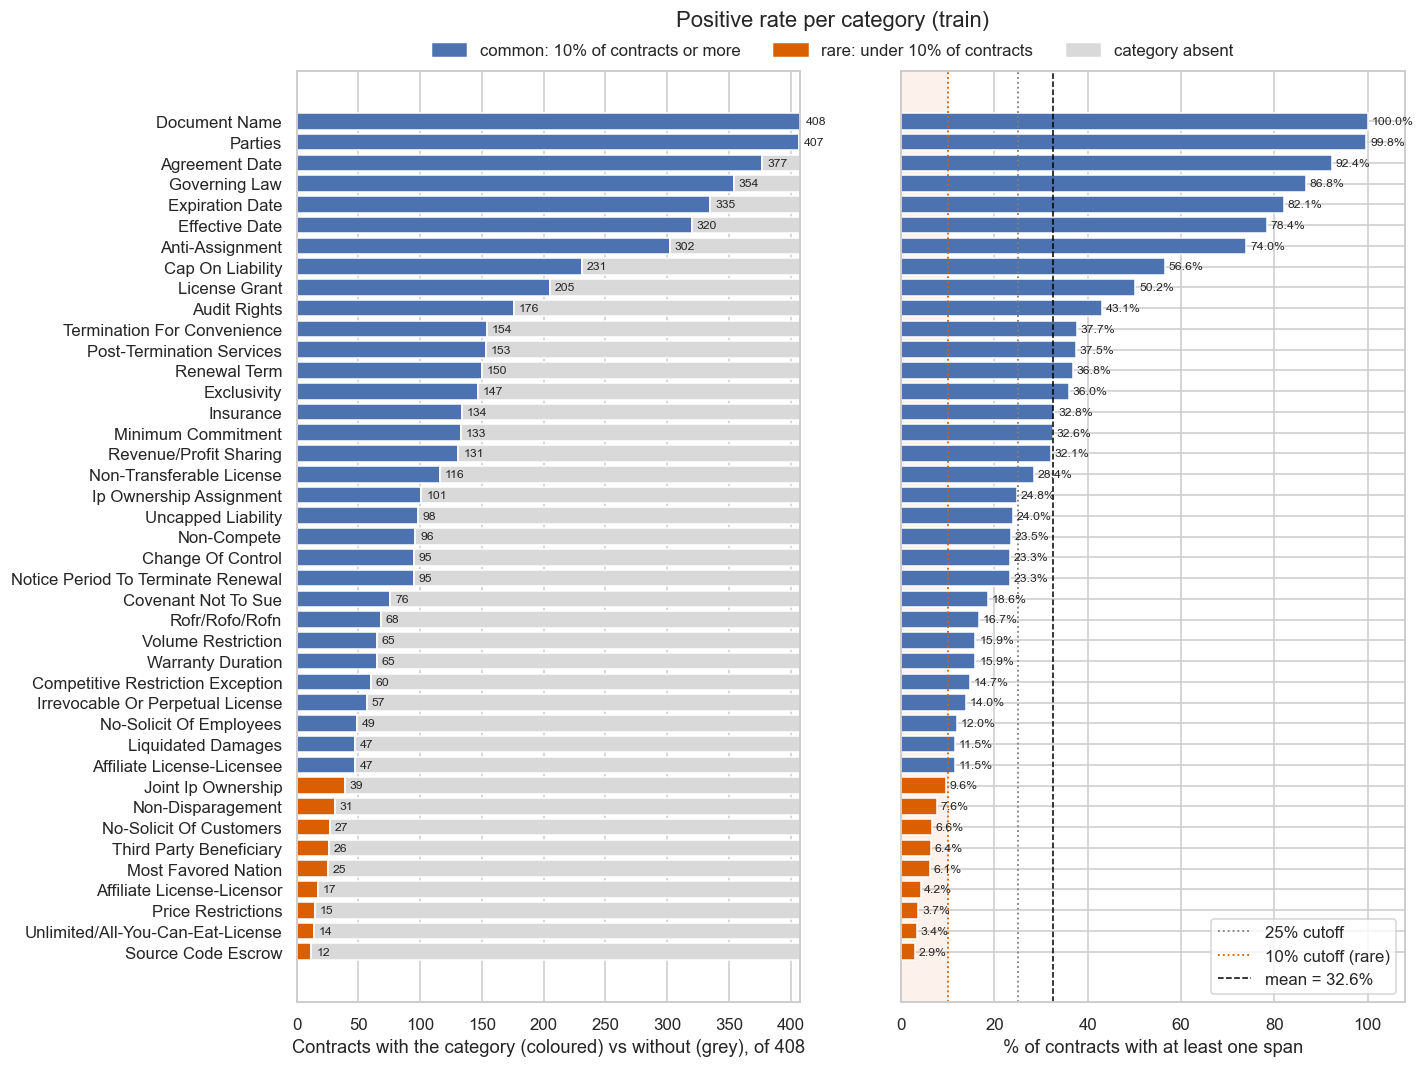

In [16]:
# positive rate per category: counts (left) and percentage (right)
order = label_table.index.tolist()                       # most to least frequent
bar_colors = np.where(label_table["rare"], ORANGE, BLUE)
n_total = int(rate["total_contracts"].iloc[0])           # 408 train contracts

fig, axes = plt.subplots(1, 2, figsize=(13, 11), sharey=True)

# left: contracts with the category vs without it (the imbalance, as counts)
with_cat = label_table["contracts_with"]
axes[0].barh(order, with_cat, color=bar_colors)
axes[0].barh(order, n_total - with_cat, left=with_cat, color=LIGHT)
for y_pos, v in enumerate(with_cat):
    axes[0].text(v + 4, y_pos, f"{int(v)}", va="center", fontsize=8)
axes[0].set_xlim(0, n_total)
axes[0].set_xlabel(f"Contracts with the category (coloured) vs without (grey), of {n_total}")

# right: the same thing as a percentage, with the section 3 cutoffs
pct = label_table["pct_contracts"]
axes[1].axvspan(0, RARE_PCT, color=ORANGE, alpha=0.08)
axes[1].barh(order, pct, color=bar_colors)
axes[1].axvline(MID_PCT, color="grey", ls=":", lw=1.2, label=f"{MID_PCT}% cutoff")
axes[1].axvline(RARE_PCT, color=ORANGE, ls=":", lw=1.2, label=f"{RARE_PCT}% cutoff (rare)")
axes[1].axvline(pct.mean(), color="black", ls="--", lw=1, label=f"mean = {pct.mean():.1f}%")
for y_pos, v in enumerate(pct):
    axes[1].text(v + 0.8, y_pos, f"{v:.1f}%", va="center", fontsize=8)
axes[1].set_xlim(0, 108)
axes[1].set_xlabel("% of contracts with at least one span")
axes[1].legend(loc="lower right", frameon=True)

axes[0].invert_yaxis()
fig.suptitle(f"Positive rate per category ({SPLIT})", y=0.93)
fig.legend(handles=[Patch(color=BLUE, label=f"common: {RARE_PCT}% of contracts or more"),
                    Patch(color=ORANGE, label=f"rare: under {RARE_PCT}% of contracts"),
                    Patch(color=LIGHT, label="category absent")],
           loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.915), frameon=False)
fig.savefig(FIG_DIR / "positive_rate_per_category.png")
plt.show()

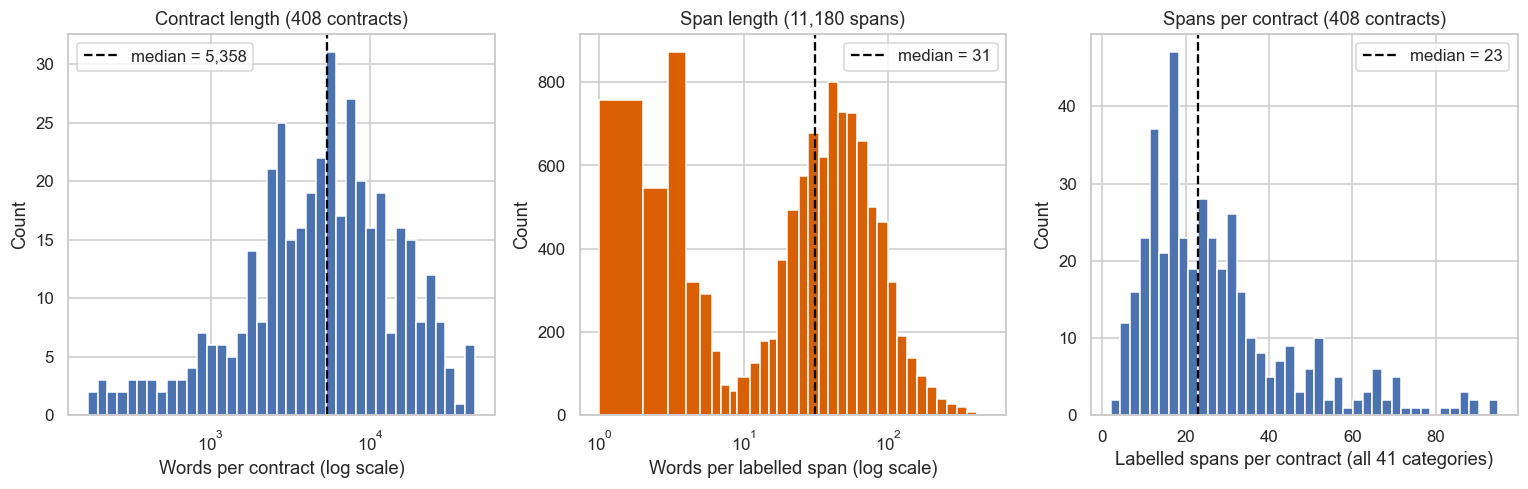

,contract_words,span_words,spans_per_contract
count,408.0,11180.0,408.0
mean,8045.1,40.8,27.4
std,8300.2,43.5,18.0
min,170.0,1.0,2.0
5%,548.5,1.0,7.4
25%,2536.8,6.0,14.0
50%,5357.5,31.0,23.0
75%,10398.2,57.0,34.0
95%,25224.1,117.0,66.0
max,45650.0,479.0,95.0


In [17]:
# contract and span distributions
def log_hist(ax, values, xlabel, title, color):
    values = values[values > 0]
    # integer bin edges, so integer word counts do not fall through log-spaced gaps
    bins = np.unique(np.round(np.logspace(np.log10(values.min()), np.log10(values.max() + 1), 40)))
    ax.hist(values, bins=bins, color=color)
    ax.set_xscale("log")
    ax.axvline(values.median(), color="black", ls="--", label=f"median = {values.median():,.0f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
log_hist(axes[0], contracts_tr["n_words"], "Words per contract (log scale)",
         f"Contract length ({len(contracts_tr)} contracts)", BLUE)
log_hist(axes[1], spans_tr["n_words"], "Words per labelled span (log scale)",
         f"Span length ({len(spans_tr):,} spans)", ORANGE)

n_sp = contracts_tr["n_spans"]
axes[2].hist(n_sp, bins=40, color=BLUE)
axes[2].axvline(n_sp.median(), color="black", ls="--", label=f"median = {n_sp.median():.0f}")
axes[2].set_xlabel("Labelled spans per contract (all 41 categories)")
axes[2].set_ylabel("Count")
axes[2].set_title(f"Spans per contract ({len(contracts_tr)} contracts)")
axes[2].legend()

fig.savefig(FIG_DIR / "contract_and_span_distributions.png")
plt.show()

q = [0.05, 0.25, 0.5, 0.75, 0.95]
dist_stats = pd.DataFrame({
    "contract_words": contracts_tr["n_words"].describe(percentiles=q),
    "span_words": spans_tr["n_words"].describe(percentiles=q),
    "spans_per_contract": n_sp.describe(percentiles=q),
}).round(1)
dist_stats.to_csv(FIG_DIR / f"distribution_stats_{SPLIT}.csv")
dist_stats

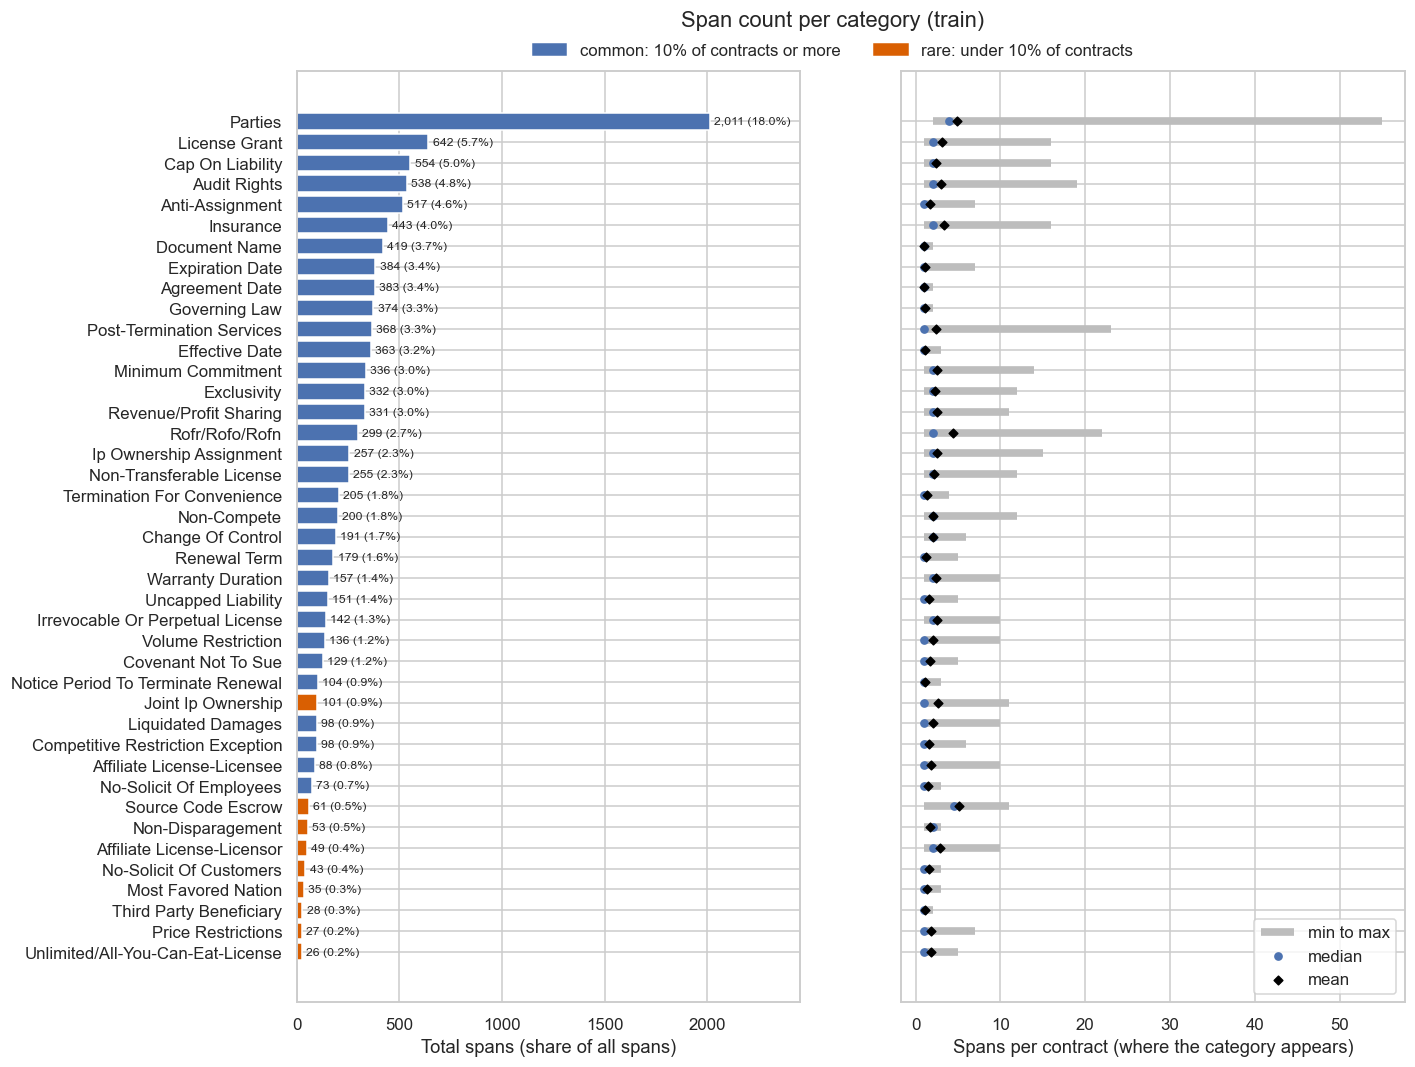

In [18]:
# span count per category
span_order = label_table.sort_values("spans", ascending=False).index.tolist()
span_colors = np.where(label_table.loc[span_order, "rare"], ORANGE, BLUE)
ypos = np.arange(len(span_order))

# spans per contract, only in contracts where the category appears (same idea as section 4)
per_contract_spread = (pres[pres["present"]].groupby("category")["n_spans"]
                       .agg(["mean", "median", "min", "max"]).loc[span_order])

fig, axes = plt.subplots(1, 2, figsize=(13, 11), sharey=True)

spans_sorted = label_table.loc[span_order, "spans"]
axes[0].barh(ypos, spans_sorted, color=span_colors)
for y_pos, v, p in zip(ypos, spans_sorted, label_table.loc[span_order, "pct_of_spans"]):
    axes[0].text(v + spans_sorted.max() * 0.01, y_pos, f"{int(v):,} ({p:.1f}%)", va="center", fontsize=8)
axes[0].set_xlim(0, spans_sorted.max() * 1.22)
axes[0].set_xlabel("Total spans (share of all spans)")

axes[1].hlines(ypos, per_contract_spread["min"], per_contract_spread["max"], color="#bdbdbd", lw=5, label="min to max")
axes[1].scatter(per_contract_spread["median"], ypos, color=BLUE, s=22, zorder=3, label="median")
axes[1].scatter(per_contract_spread["mean"], ypos, color="black", marker="D", s=16, zorder=3, label="mean")
axes[1].set_xlabel("Spans per contract (where the category appears)")
axes[1].legend(loc="lower right", frameon=True)

axes[0].set_yticks(ypos)
axes[0].set_yticklabels(span_order)
axes[0].invert_yaxis()
fig.suptitle(f"Span count per category ({SPLIT})", y=0.93)
fig.legend(handles=[Patch(color=BLUE, label=f"common: {RARE_PCT}% of contracts or more"),
                    Patch(color=ORANGE, label=f"rare: under {RARE_PCT}% of contracts")],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.915), frameon=False)
fig.savefig(FIG_DIR / "span_count_per_category.png")
plt.show()